# Step 1: Data Cleaning & Type Conversion

Objectives:

Standardize data types for numerical analysis.

Handle missing values in critical columns like TotalCharges.

Key Action:
The TotalCharges column was initially stored as an 'object' (string). I converted it to a numeric float and handled empty strings by filling them with 0 to ensure computational stability.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read data from link
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

# Browse first 5 rows
#print(df.head())

# Check data type
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


TotalCharges data type=object, it need to change into float64 for analysis

In [2]:
# convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

Data checking after data transformation

In [3]:
# 1. Check for Missing values
print("Missing values count:")
print(df.isnull().sum())

Missing values count:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [4]:
# Find reocrds for Null TotalCharges
null_data = df[df['TotalCharges'].isnull()]

# List the 11 records
print(f"There are {len(null_data)} Null records：")
display(null_data[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

There are 11 Null records：


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


All the Null TotalCharges records are New Customer (Tenure=0). Remove those 11 incompleted records from total 7043 records will not bring significant impact.   

In [5]:
# Remove entries with NaN value
df=df.dropna()

# Data Integrity: Remove duplicates based on unique identifier
df = df.drop_duplicates(subset='customerID').copy()

# Label Encoding: df['Churn'] Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Consistency Check
# Check if unique value
print(f"data value in MultipleLines :\n{df['MultipleLines'].unique()}")

# Standardize value for "No internet service" or "No phone service" to "No"
cols_to_fix = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

print(f"Data Cleaning Complete. Remaining Nulls:\n{df.isnull().sum()}")

data value in MultipleLines :
['No phone service' 'No' 'Yes']
Data Cleaning Complete. Remaining Nulls:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# EDA
1. Contract type characteristics
2. Internet Service characteristics

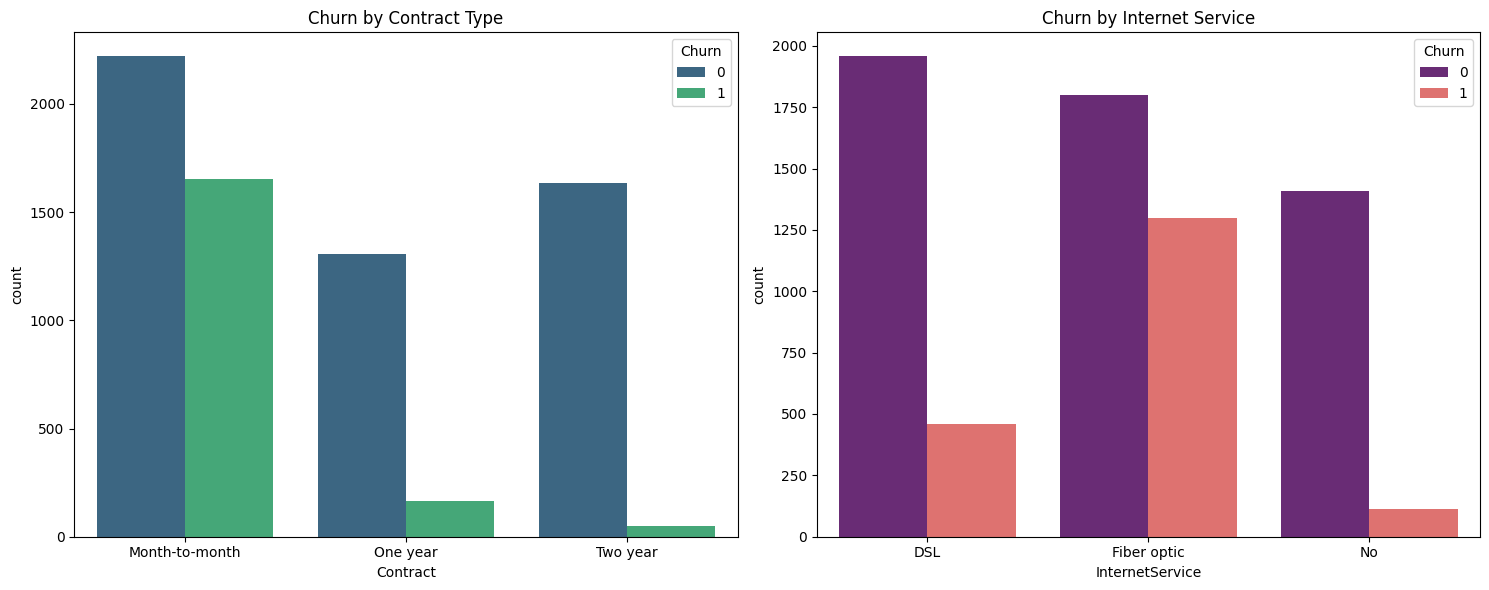

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# set up chart size
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1： Churn by Contract Type 
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0], palette='viridis')
axes[0].set_title('Churn by Contract Type')

# Chart 2：Churn by Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1], palette='magma')
axes[1].set_title('Churn by Internet Service')

plt.tight_layout()
plt.show()

Key Findings from EDA:

Retention Driver: Contract type is the strongest predictor. Customers on month-to-month plans are significantly more likely to churn compared to those on 1-year or 2-year contracts.

Service Risk: Fiber optic users show a disproportionately high churn rate, suggesting potential issues with service pricing or technical stability in this segment.

# Step 2: Feature Engineering & One-Hot Encoding

Methodology:

Irrelevant Feature Removal: Removed customerID as it contains no predictive power.

One-Hot Encoding: Applied pd.get_dummies to transform categorical variables (e.g., Internet Service, Contract type) into a numeric format (0 and 1).

Multicollinearity Prevention: Used drop_first=True to avoid the "Dummy Variable Trap," ensuring the model remains statistically robust.

In [7]:
# Checking "Object" from df (They will perform transform in Get_Dummies() )
print(df.select_dtypes(include=['object']).columns)

# Checking "Numeric" colume (They will skip in Get_Dummies())
print(df.select_dtypes(include=['number']).columns)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')


In [8]:
# 1. Remove unuse column
df_model = df.drop(columns=['customerID'])

# 2. One-Hot Encoding (transform Categorical Data into 0 & 1)
#df_encoded = pd.get_dummies(df_model, drop_first=True)
df_encoded = pd.get_dummies(df_model)

# 3. Checking
print(f"There are  {df_encoded.shape[1]} columns after One-Hot Encoding")
df_encoded.head()

There are  39 columns after One-Hot Encoding


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,True,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,0,False,True,True,False,True,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,0,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,1,True,False,True,False,True,...,False,True,False,False,False,True,False,False,True,False


# Step 3: Statistical Correlation Analysis

Findings:
By calculating the correlation between the features and the target variable (Churn), I identified that Contract Type (Month-to-month) and Internet Service (Fiber optic) have the strongest positive correlation with churn. Conversely, Tenure shows a strong negative correlation, suggesting that longer-term loyalty significantly reduces churn risk. 

These statistical findings serve as the foundation for feature selection in our machine learning phase (Step 4).

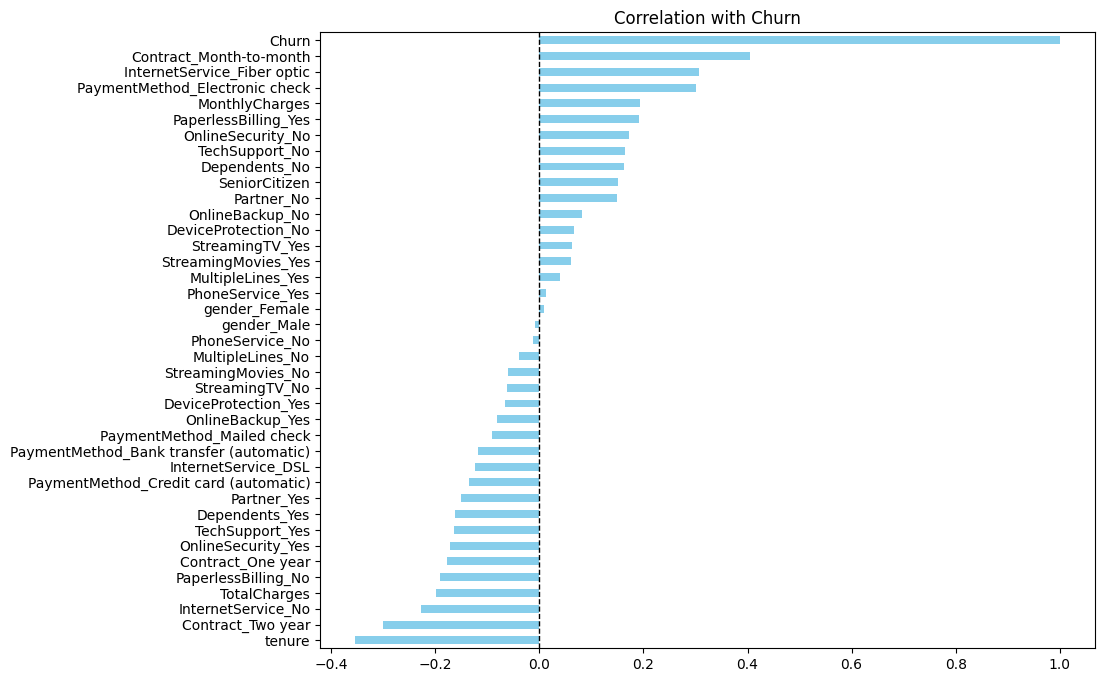

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = 'Churn' if 'Churn' in df_encoded.columns else 'Churn_Yes'

correlations = df_encoded.corr()[target_col].sort_values(ascending=True)

plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color='skyblue')
plt.title(f'Correlation with {target_col}')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1) # insert 0 baseline
plt.show()

# Step 4: Machine Learning Model (XGBoost) & Class Imbalance Handling

Challenge:
The dataset is imbalanced, with far fewer churned customers than active ones. A standard model would be biased towards predicting "No Churn."

Strategy:

Implemented XGBoost Classifier for its superior performance on tabular data.

Applied scale_pos_weight (Ratio: ~2.76) to penalize misclassifications of the minority class (Churned customers).

Impact:
This adjustment successfully shifted the model's focus to Recall, which is more critical for retention business strategies.

In [10]:
from sklearn.model_selection import train_test_split

# Def features (X) and target (y)
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# Splite：80% training，20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training sample: {X_train.shape[0]}, Test sample: {X_test.shape[0]}")

Training sample: 5625, Test sample: 1407


In [11]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Build and training the model
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Result
print("--- Model estimate report ---")
print(classification_report(y_test, y_pred))

--- Model estimate report ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



The classification repsort show F-value of Churn=1 just 0.55 and only 0.49 can recall correctly. 

Handling Class Imbalance
The result show count[0]=1033 and count[1]=374,
the imbalance ratio = 1033/374 = 2.76

Class imbalance can be adjusted by using scale_pos_weight parameter in XGBoost

In [12]:
# Calculate the ratio of 2 class: (1033 / 374 ≒ 2.76)
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5,
    scale_pos_weight=ratio  # Introduct this ratio to increase number of Recall
)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Result
print("--- Model estimate report ---")
print(classification_report(y_test, y_pred))

--- Model estimate report ---
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1033
           1       0.50      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.74      0.75      1407



# Step 5: Evaluation & Business Impact Analysis

Metric Interpretation:

Recall (0.76): The model effectively captures 76% of all customers who are likely to leave.

Precision (0.50): While the precision is lower, the model prioritizes identifying as many at-risk customers as possible to minimize lost revenue.

Confusion Matrix Insights:
Out of 374 actual churn cases, the model correctly 

<Figure size 800x600 with 0 Axes>

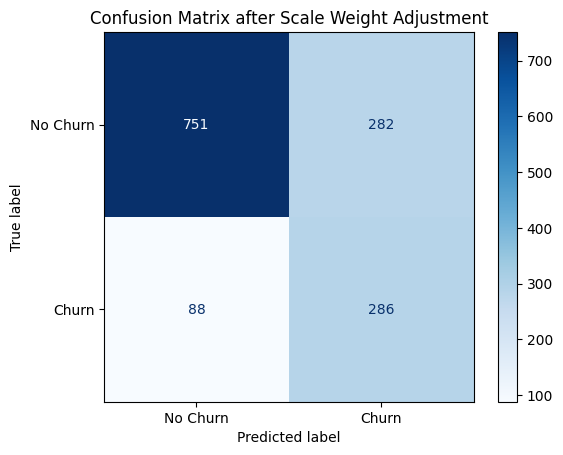

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=['No Churn', 'Churn'], cmap='Blues')
plt.title('Confusion Matrix after Scale Weight Adjustment')
plt.show()

# Step 6: Model Insights & Strategic Recommendations

Top Predictors:
The XGBoost Feature Importance plot confirms that Month-to-month contracts and Fiber optic service are the primary drivers of churn. This aligns perfectly with the initial EDA.

Final Business Recommendations:

Contract Migration: Launch targeted marketing campaigns to incentivize "Month-to-month" customers to transition to "One-year" or "Two-year" contracts.

Service Quality Audit: Investigate the high churn rate among Fiber Optic users—is it due to pricing, technical issues, or competitor poaching?

Proactive Retention: Use the model’s predictions to offer loyalty rewards to the 76% of at-risk customers identified before they terminate their service.

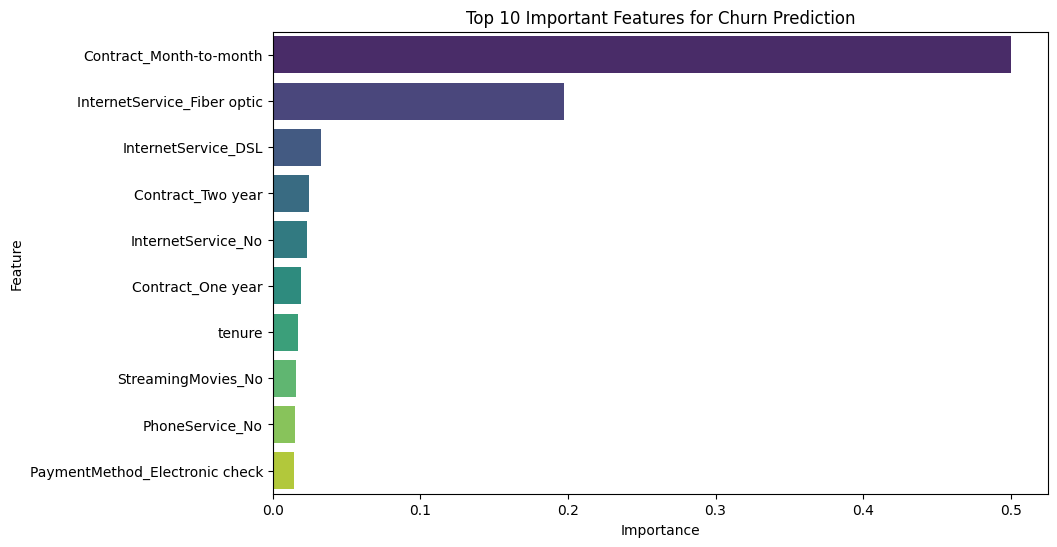

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# What feature importance learn from the model
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Top10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10),hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Important Features for Churn Prediction')
plt.show()